model training

In [1]:
import pandas as pd
import os
import numpy as np

cancerous = ['BCC','MEL','SCC']
not_cancerous = ['ACK', 'NEV', 'SEK']

In [2]:
df = pd.read_csv('../data/metadata.csv')
df.head()



,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [3]:
mask_dir = "../data/masks"

necessary_df = df[
    df['img_id'].apply(lambda x: os.path.exists(f"{mask_dir}/{x.removesuffix(".png")}_mask.png"))][['img_id', 'diagnostic']].copy()
necessary_df['cancerous'] = necessary_df['diagnostic'].isin(cancerous)

df_sample = necessary_df.sample(n=200, random_state=42)
df_sample.head()


,img_id,diagnostic,cancerous
2017,PAT_537_1014_452.png,SCC,True
382,PAT_770_1451_136.png,SCC,True
1775,PAT_1247_852_178.png,ACK,False
310,PAT_270_1382_561.png,SEK,False
200,PAT_1298_1051_831.png,NEV,False


In [4]:
print("CWD:", os.getcwd())
print("Mask dir exists:", os.path.exists("../data/masks"))
print(os.listdir(mask_dir)[:10])

CWD: d:\aa-DS-project-tigers\2026-PDS-Tigers\src
Mask dir exists: True
['.DS_Store', '.gitkeep', 'PAT_1000_31_620_mask.png', 'PAT_1006_53_385_mask.png', 'PAT_1006_53_716_mask.png', 'PAT_1008_59_297_mask.png', 'PAT_100_393_898_mask.png', 'PAT_1013_82_876_mask.png', 'PAT_1014_86_861_mask.png', 'PAT_1017_97_577_mask.png']


In [5]:
from asymmetry import extract_asymmetry  
from border import border
from color import color_features_extraction

In [7]:
import numpy as np

def safe_color_features_extraction(img_id):
    try:
        return color_features_extraction(img_id)
    except ValueError:  # catches the "more dimensions than allowed" error
        return np.nan

# Apply the safe version
df_sample['color'] = df_sample['img_id'].apply(safe_color_features_extraction)


In [8]:
df_sample.head()
nan_count = df_sample['color'].isna().sum()
nan_count


np.int64(7)

In [8]:
df_sample['assymetry'] = df_sample['img_id'].apply(extract_asymmetry)


In [9]:
df_sample['border'] = df_sample['img_id'].apply(border)

d:\aa-DS-project-tigers\2026-PDS-Tigers\src\border.py:35: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  mask_eroded = morphology.binary_erosion(mask, struct_el)


In [10]:
df_sample.head()

,img_id,diagnostic,cancerous,color,assymetry,border
1280,PAT_762_1436_414.png,BCC,True,"[41.600197, 17.465927, 3.9685292, -0.1865768, ...",0.321699,"[0.009657529937054076, 0.6444641186928366]"
728,PAT_735_1391_683.png,ACK,False,"[35.63798, 9.361398, 7.0982823, 0.19028279, 0....",0.352734,"[0.0025975470601312138, 0.5983695228681681]"
450,PAT_467_904_235.png,BCC,True,"[45.33071, 16.266077, 8.767087, 0.089915365, 0...",0.609179,"[0.019134302749854636, 0.25629495986861883]"
265,PAT_121_184_502.png,BCC,True,"[60.344635, 38.436214, 41.583466, 0.29437166, ...",0.168817,"[0.010168245479361772, 0.5482704500356075]"
1298,PAT_645_1223_443.png,BCC,True,"[26.447027, 17.459753, 5.0061035, -0.14742374,...",0.401232,"[0.002966817121905673, 0.42987161616106845]"


In [11]:
df_sample = df_sample.dropna()

In [12]:
color_df = pd.DataFrame(df_sample['color'].tolist(), columns=['Ls_value', 'as_value', 'bs_value', 'mean_angle_h', 's_value', 'v_value', 'r_value', 'g_value', 'b_value','Ls_var', 'as_var', 'bs_var', 'h_var', 's_var', 'v_var', 'r_var', 'g_var', 'b_var', 'hsv_var_mean', 'rgb_var_mean', 'hsv_var_mag', 'rgb_var_mag', 'circular_max_min_h'])

In [13]:
border_df = pd.DataFrame(df_sample['border'].tolist(), columns=['compactness', 'convexity'])
border_df

,compactness,convexity
0,0.009658,0.644464
1,0.002598,0.598370
2,0.019134,0.256295
3,0.010168,0.548270
4,0.002967,0.429872
...,...,...
349,0.035231,0.619882
350,0.006503,0.517630
351,0.007493,0.572862
352,0.001695,0.552625


In [14]:
color_df.shape

(354, 23)

In [15]:
## SVM Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
import pandas as pd

# Features and labels
x = pd.concat([
    color_df.reset_index(drop=True),
    df_sample[['assymetry']].reset_index(drop=True),
    border_df.reset_index(drop=True)
], axis=1)

y = df_sample['cancerous']

# Train/test split
dev_x, test_x, dev_y, test_y = train_test_split(
    x, y, stratify=y, random_state=0, test_size=0.2
)

# 🔹 Pipeline (scaling + SVM)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

# 🔹 Parameter grid (note the prefix 'svm__')
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001]
}

# 🔹 GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Train
grid_search.fit(dev_x, dev_y)

# --- RESULTS ---
print("Best Params:", grid_search.best_params_)
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# 🔹 Test evaluation
best_model = grid_search.best_estimator_

# Probabilities for class 1
y_probs = best_model.predict_proba(test_x)[:, 1]

test_auc = roc_auc_score(test_y, y_probs)

print(f"Final Test AUC: {test_auc:.4f}")

Best Params: {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Best CV AUC: 0.7411
Final Test AUC: 0.7599


Text(0.5, 1.0, 'g_value')

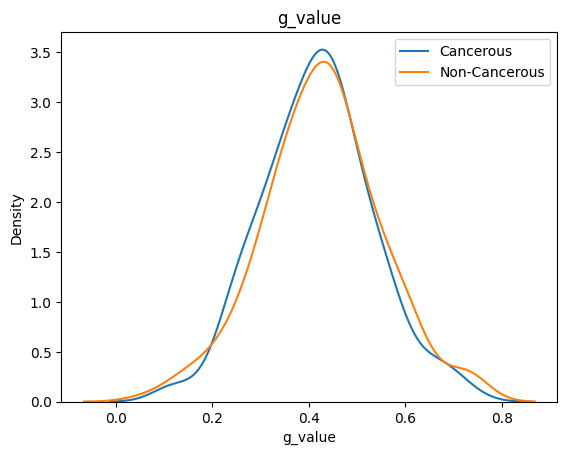

In [46]:
#### kde plots
#[Ls_value, as_value, bs_value, mean_angle_h, s_value, 
# v_value, r_value, g_value, b_value,Ls_var, as_var, bs_var, 
# h_var, s_var, v_var, r_var, g_var, b_var, hsv_var_mean, rgb_var_mean, 
# hsv_var_mag, rgb_var_mag, circular_max_min_h]

xy_df = pd.concat([x.reset_index(drop=True), y.reset_index(drop=True)], axis = 1)

cancerous = xy_df[xy_df['cancerous'] == True].copy()
not_cancerous = xy_df[xy_df['cancerous'] == False].copy()



import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(cancerous['g_value'], label="Cancerous")
sns.kdeplot(not_cancerous['g_value'], label="Non-Cancerous")
plt.legend()
plt.title("g_value")

###########################################################################################################################

In [15]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

x = pd.concat([color_df.reset_index(drop=True), df_sample[['assymetry']].reset_index(drop=True), border_df.reset_index(drop=True)], axis=1)
y = df_sample['cancerous']

dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0, test_size=0.2)









#### standardisation

In [16]:
# 2. Standardize the data
scaler = StandardScaler()

# Fit and transform the development data
dev_x_scaled = scaler.fit_transform(dev_x)

# ONLY transform the test data (using dev_x's mean and std)
test_x_scaled = scaler.transform(test_x)



In [17]:
knn = KNeighborsClassifier()

# Define the k values to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19]
}

# 4. Run Grid Search with 5-fold CV and AUC scoring
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


grid_search.fit(dev_x_scaled, dev_y)

# --- RESULTS ---

print(f"Best k value: {grid_search.best_params_['n_neighbors']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# 5. Final check on the Test Set
best_model = grid_search.best_estimator_
test_auc = best_model.score(test_x_scaled, test_y)

print(f"Final Test AUC: {test_auc:.4f}")

Best k value: 9
Best CV AUC: 0.6770
Final Test AUC: 0.6197


### Plotting based on features

--- Top Linear Correlations ---
target                1.000000
h_var                 0.229795
circular_max_min_h    0.227062
compactness           0.192320
hsv_var_mag           0.172743
hsv_var_mean          0.171461
bs_var                0.143501
s_value               0.136762
bs_value              0.060181
as_value              0.001567
s_var                -0.007583
convexity            -0.041787
v_var                -0.044434
as_var               -0.051624
r_var                -0.056358
b_var                -0.063372
Ls_var               -0.076806
v_value              -0.081742
rgb_var_mean         -0.085241
r_value              -0.089296
rgb_var_mag          -0.089297
Ls_value             -0.112606
g_var                -0.118933
g_value              -0.120155
mean_angle_h         -0.139924
b_value              -0.147202
assymetry            -0.173167
Name: target, dtype: float64

--- Mutual Information Scores ---
as_value              0.096078
s_value               0.074863
assym

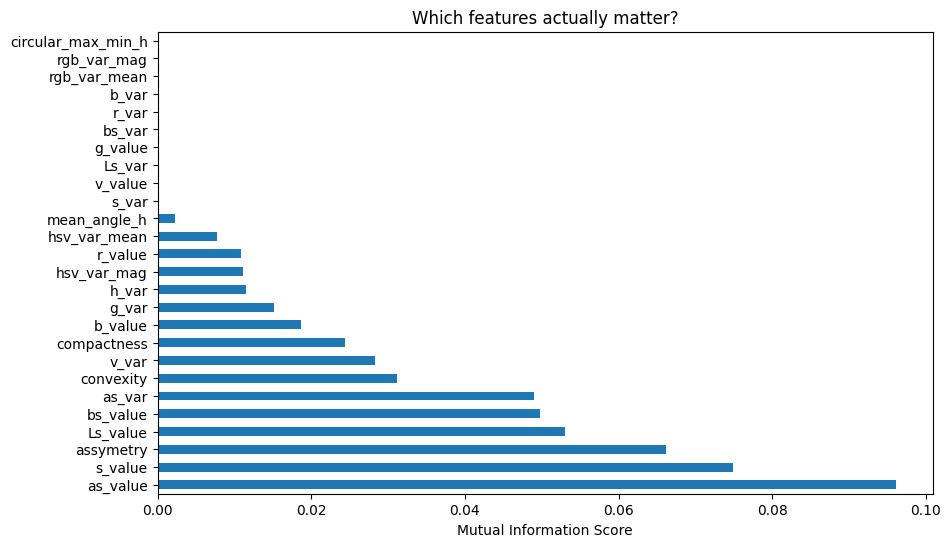

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1. Simple Correlation (Linear)
# We look at how much each column relates to 'y'
# Assuming x is a DataFrame and y is a Series
df = x.copy()
df['target'] = y
correlations = df.corr()['target'].sort_values(ascending=False)

print("--- Top Linear Correlations ---")
print(correlations)

# 2. Mutual Information (Non-Linear)
# This is GREAT for KNN because it captures any kind of relationship
# 0 = no relationship, higher = stronger relationship
mi_scores = mutual_info_classif(x, y, random_state=0)
mi_series = pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_series = mi_series.sort_values(ascending=False)

print("\n--- Mutual Information Scores ---")
print(mi_series)

# 3. Quick Visualization
plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh')
plt.title("Which features actually matter?")
plt.xlabel("Mutual Information Score")
plt.show()

In [20]:
important_features = ['assymetry', 'as_value','s_value', 'Ls_value', 'bs_value', 'as_var', 'convexity', 'compactness']
x_filtered = x[important_features]

# 2. Re-split with the filtered features
dev_x, test_x, dev_y, test_y = train_test_split(
    x_filtered, y, stratify=y, random_state=0, test_size=0.2
)

# 3. Scale ONLY these 3 features
scaler = StandardScaler()
dev_x_scaled = scaler.fit_transform(dev_x)
test_x_scaled = scaler.transform(test_x)

# 4. Re-run your Grid Search (using the code from before)
grid_search.fit(dev_x_scaled, dev_y)

print(f"New Best CV AUC: {grid_search.best_score_:.4f}")

New Best CV AUC: 0.7178
